In [2]:
# 0. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
# 1. 전처리 전 원본 데이터 로드
# 생존 분석은 Tenure(재직기간)와 Churn이 필요
# 인코딩 전 원본 데이터 사용
import openpyxl
df = pd.read_excel('../data/Ecommerce_Dataset.xlsx', sheet_name='E Comm')
df = df.drop_duplicates()
df = df.dropna(subset=['Tenure', 'Churn'])

print(f'데이터 크기: {df.shape[0]:,}행')
print(f'Churn 비율: {df["Churn"].mean()*100:.1f}%')

데이터 크기: 5,366행
Churn 비율: 16.2%


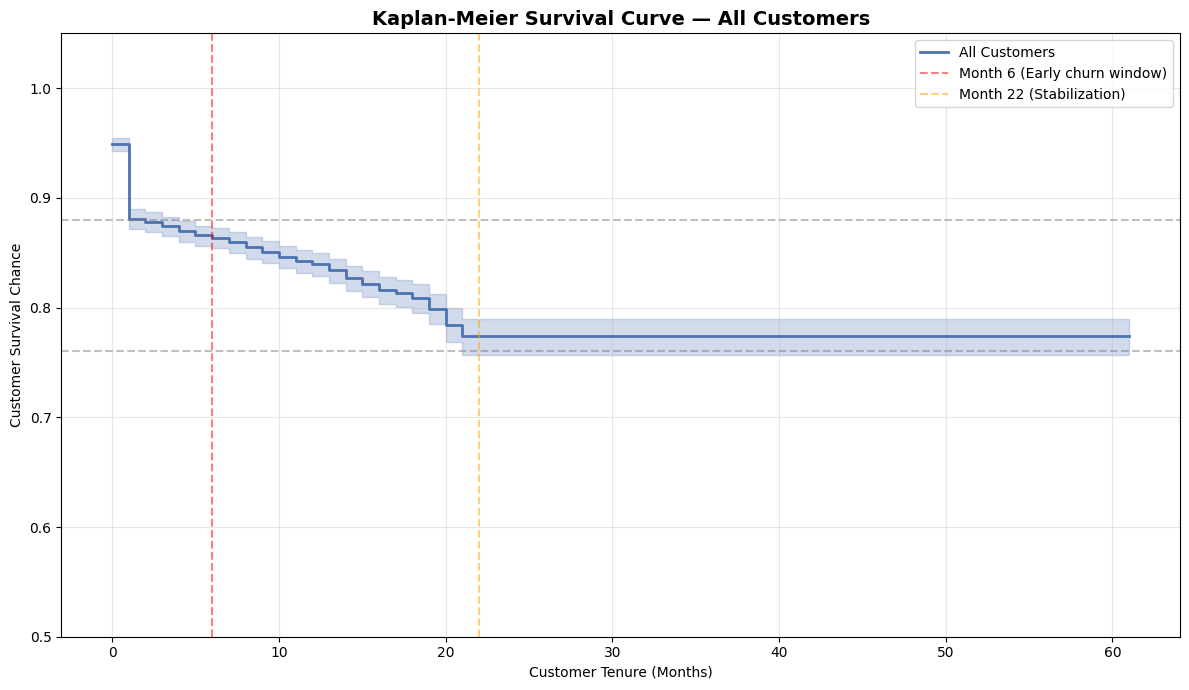


=== Survival Probability at Key Timepoints ===
  Month  0: 0.949
  Month  6: 0.864
  Month 12: 0.840
  Month 18: 0.809
  Month 22: 0.774
  Month 30: 0.774
  Month 60: 0.774


In [4]:
# 2. Kaplan-Meier 생존 분석 (논문 Fig 3 재현)
# S(t) = P(T > t) : t 시점 이후에도 살아있을 확률 (이탈 안 할 확률)

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df['Tenure'],   # 고객 재직기간
    event_observed=df['Churn'],  # 1 = 이탈 발생
    label='All Customers'
)

plt.figure(figsize=(12, 7))
kmf.plot_survival_function(
    ci_show=True,        # 신뢰구간 표시
    color='#4C72B0',
    linewidth=2
)

# 논문 주요 포인트 표시
plt.axhline(y=0.88, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=6, color='red', linestyle='--', alpha=0.5, label='Month 6 (Early churn window)')
plt.axhline(y=0.76, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=22, color='orange', linestyle='--', alpha=0.5, label='Month 22 (Stabilization)')

plt.title('Kaplan-Meier Survival Curve — All Customers', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Customer Survival Chance')
plt.legend(fontsize=10)
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/05_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()

# 주요 수치 확인
print('\n=== Survival Probability at Key Timepoints ===')
timeline = [0, 6, 12, 18, 22, 30, 60]
for t in timeline:
    prob = kmf.survival_function_at_times(t).values[0]
    print(f'  Month {t:>2}: {prob:.3f}')

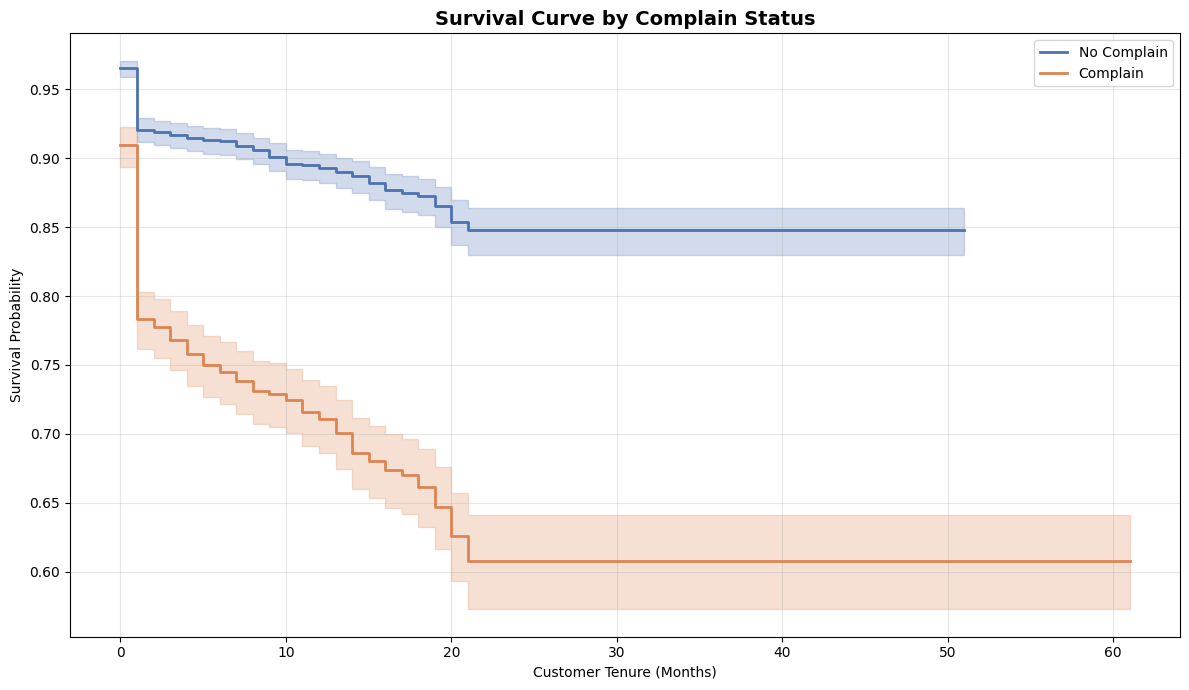


Log-rank test p-value: 0.0000
→ 두 그룹 차이가 통계적으로 유의함


In [5]:
# 3. 그룹별 생존 곡선 비교 (Complain 여부)
# 논문 인사이트: Complain이 가장 큰 이탈 신호

kmf_no_complain = KaplanMeierFitter()
kmf_complain = KaplanMeierFitter()

kmf_no_complain.fit(
    durations=df[df['Complain'] == 0]['Tenure'],
    event_observed=df[df['Complain'] == 0]['Churn'],
    label='No Complain'
)
kmf_complain.fit(
    durations=df[df['Complain'] == 1]['Tenure'],
    event_observed=df[df['Complain'] == 1]['Churn'],
    label='Complain'
)

plt.figure(figsize=(12, 7))
kmf_no_complain.plot_survival_function(ci_show=True, color='#4C72B0', linewidth=2)
kmf_complain.plot_survival_function(ci_show=True, color='#DD8452', linewidth=2)

plt.title('Survival Curve by Complain Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/05_survival_by_complain.png', dpi=150, bbox_inches='tight')
plt.show()

# Log-rank test (두 그룹 차이가 통계적으로 유의한지)
result = logrank_test(
    df[df['Complain'] == 0]['Tenure'],
    df[df['Complain'] == 1]['Tenure'],
    event_observed_A=df[df['Complain'] == 0]['Churn'],
    event_observed_B=df[df['Complain'] == 1]['Churn']
)
print(f'\nLog-rank test p-value: {result.p_value:.4f}')
print('→ 두 그룹 차이가 통계적으로 유의함' if result.p_value < 0.05 else '→ 유의하지 않음')

In [6]:
# 4. 생존 분석 요약 (논문 결과 비교)
print('=' * 55)
print('📋 Survival Analysis Summary')
print('=' * 55)
print()
print('논문 주요 결과:')
print('  Month  0 → S(t) ≈ 0.95  (초기)')
print('  Month  6 → S(t) ≈ 0.86~0.88  (급격한 초기 이탈)')
print('  Month 22 → S(t) ≈ 0.76~0.78  (안정화 시작)')
print('  Month 60 → S(t) ≈ 0.76  (plateau)')
print()
print('재현 결과:')
timeline = [0, 6, 22, 60]
for t in timeline:
    prob = kmf.survival_function_at_times(t).values[0]
    print(f'  Month {t:>2} → S(t) ≈ {prob:.3f}')
print()
print('핵심 인사이트:')
print('  → 초반 6개월이 리텐션 황금 타이밍!')
print('  → 6개월 이후 살아남은 고객은 이탈 위험 급감')
print('  → 장기 고객에겐 VIP 혜택으로 유지 전략')
print()
print('➡️  Next: 06_rfm.ipynb')

📋 Survival Analysis Summary

논문 주요 결과:
  Month  0 → S(t) ≈ 0.95  (초기)
  Month  6 → S(t) ≈ 0.86~0.88  (급격한 초기 이탈)
  Month 22 → S(t) ≈ 0.76~0.78  (안정화 시작)
  Month 60 → S(t) ≈ 0.76  (plateau)

재현 결과:
  Month  0 → S(t) ≈ 0.949
  Month  6 → S(t) ≈ 0.864
  Month 22 → S(t) ≈ 0.774
  Month 60 → S(t) ≈ 0.774

핵심 인사이트:
  → 초반 6개월이 리텐션 황금 타이밍!
  → 6개월 이후 살아남은 고객은 이탈 위험 급감
  → 장기 고객에겐 VIP 혜택으로 유지 전략

➡️  Next: 06_rfm.ipynb
